# diamonds

In [3]:
import seaborn as sns
import pandas as pd
from matplotlib import pyplot as plt
%matplotlib inline

In [ ]:
# Seaborn에 내장된 'diamonds' 데이터셋 로드
# 다이아몬드의 특성(carat, cut, color, clarity 등)과 가격(price) 정보를 포함한 회귀 분석용 데이터
df = sns.load_dataset('diamonds')

In [5]:
print(type(df))

<class 'pandas.core.frame.DataFrame'>


In [6]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [7]:
df.tail()

,carat,cut,color,clarity,depth,table,price,x,y,z
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74
53939,0.75,Ideal,D,SI2,62.2,55.0,2757,5.83,5.87,3.64


In [8]:
print(df.shape)

(53940, 10)


In [9]:
df.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


In [11]:
df.isnull().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

In [12]:
df.dropna(inplace=True)

In [13]:
df.isnull().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

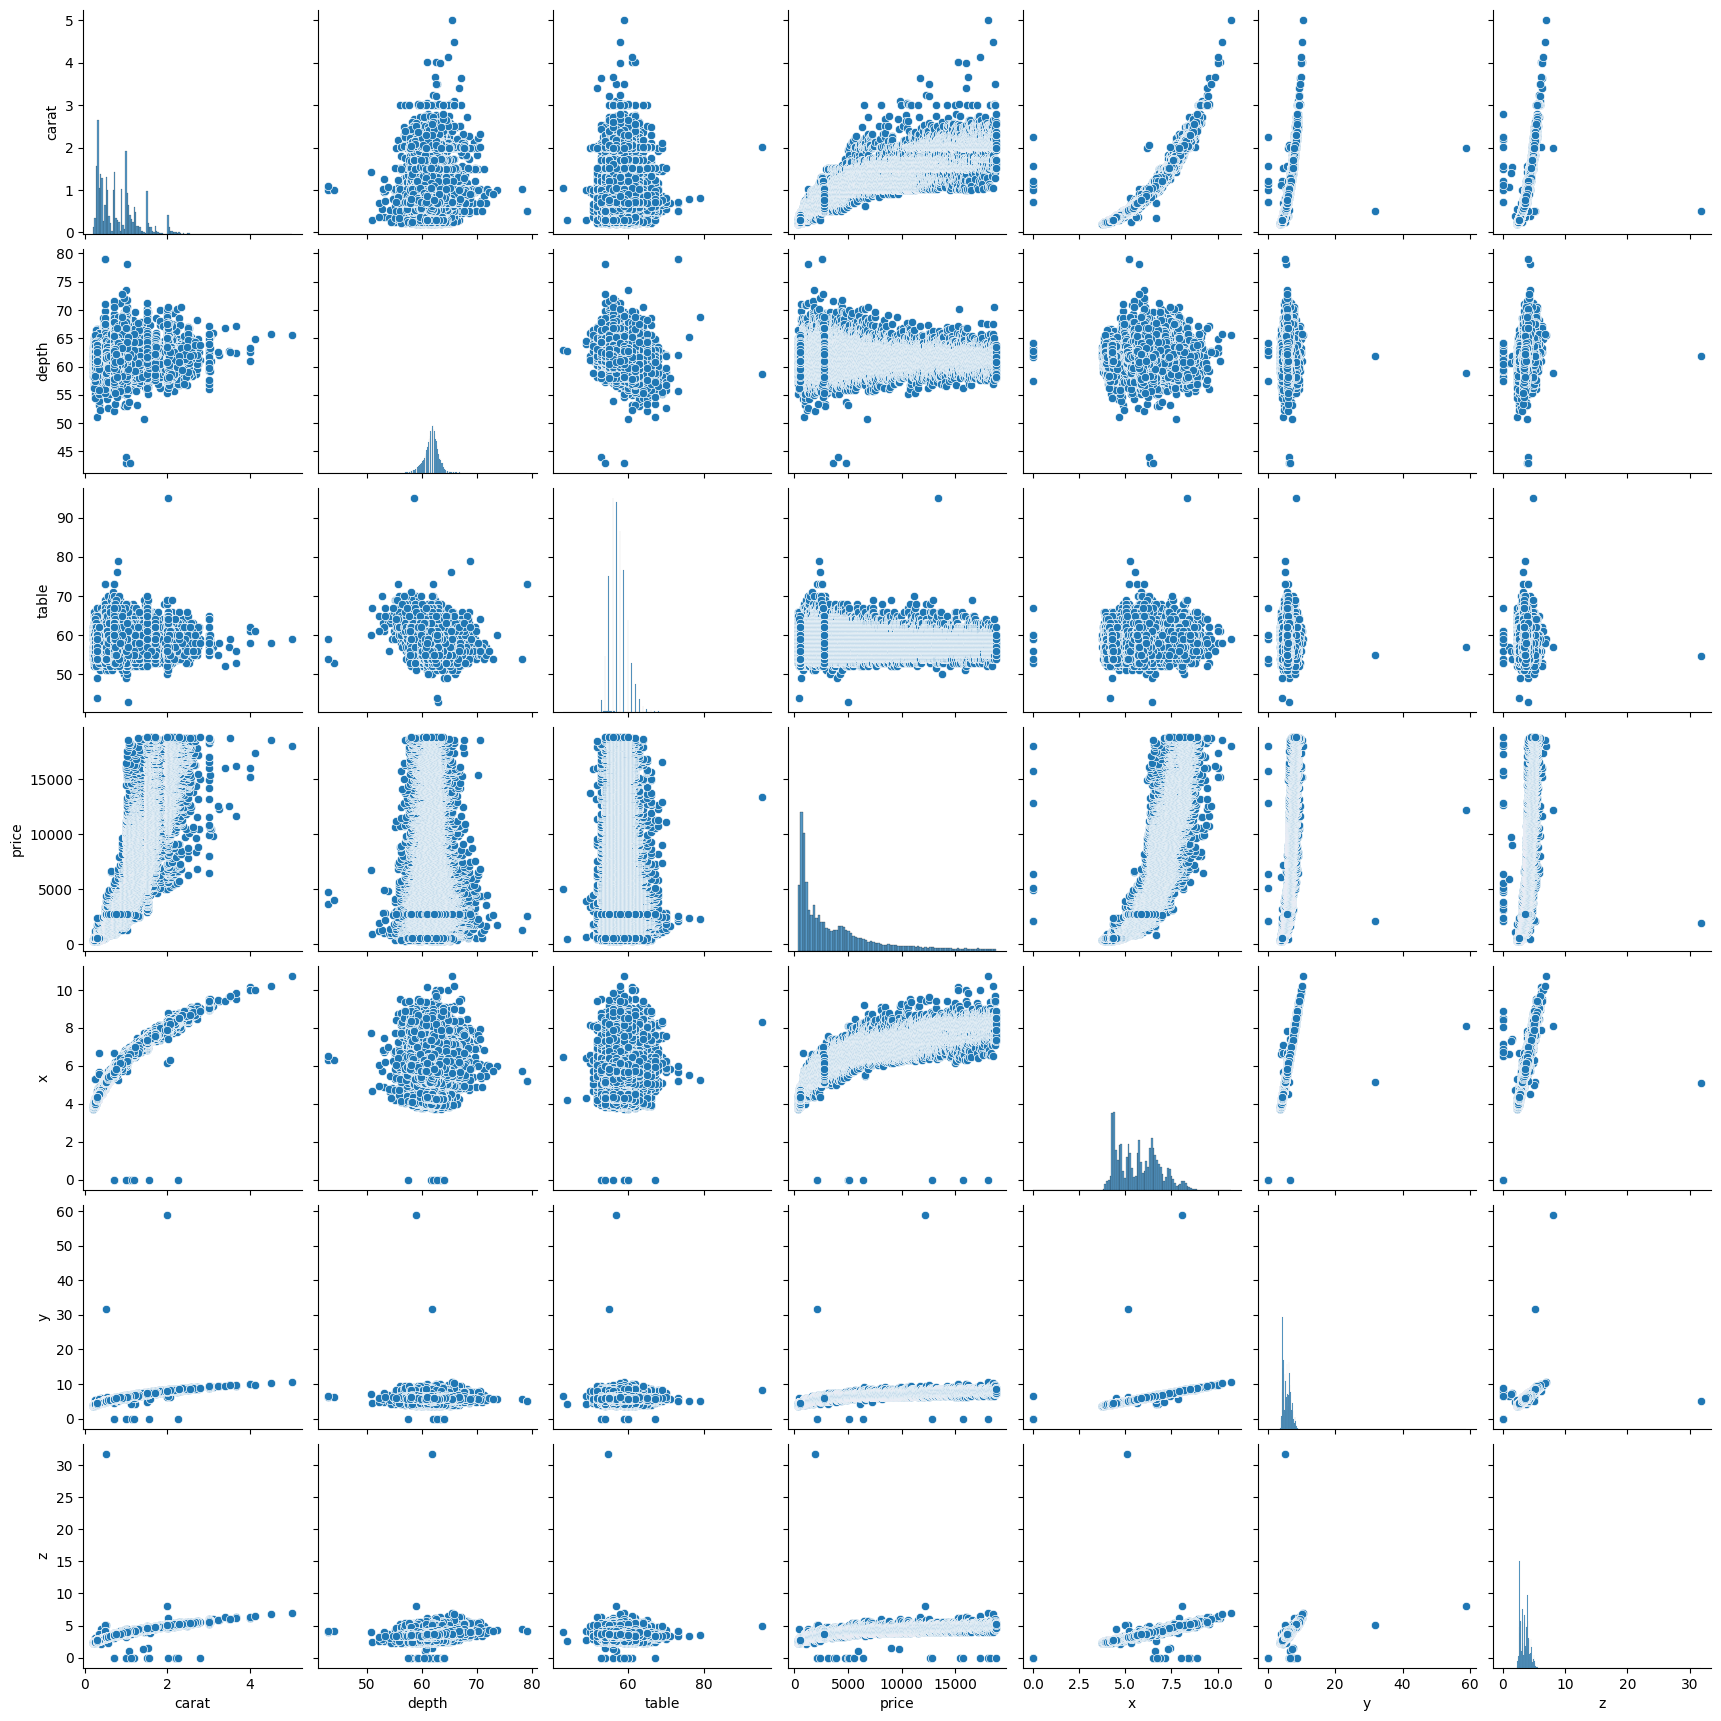

In [14]:
# 데이터프레임의 여러 변수들 간의 관계를 산점도(scatter)와 히스토그램으로 한 번에 시각화하는 pairplot 생성
sns.pairplot(df)

<Axes: xlabel='cut', ylabel='carat'>

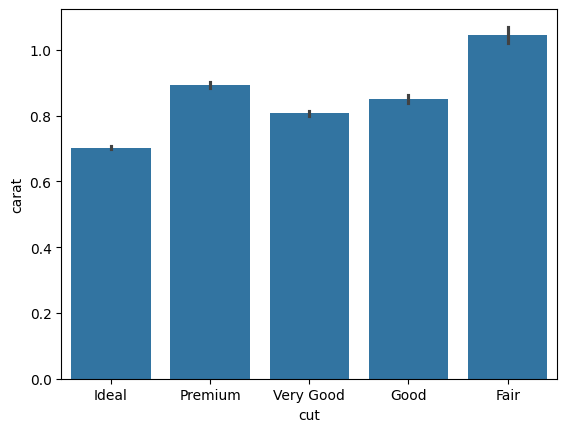

In [15]:
# 다이아몬드의 컷(cut) 등급별 평균 캐럿(carat) 값을 막대그래프로 시각화
sns.barplot(x='cut', y='carat', data=df)

<Axes: xlabel='cut', ylabel='price'>

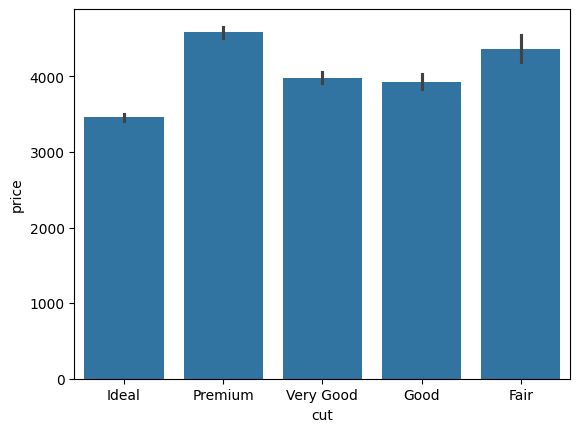

In [ ]:
# 다이아몬드의 컷(cut) 등급별 평균 가격(price) 값을 막대그래프로 시각화
sns.barplot(x='cut', y='price', data=df)

In [16]:
import pandas as pd

# 각 컬럼의 데이터 타입에 따라 적용할 집계(aggregation) 함수를 결정하는 사용자 정의 함수
def agg_func(col):

    # 범주형(categorical) 또는 문자열(object) 타입이면 → 개수(count)로 집계
    if pd.api.types.is_categorical_dtype(col) or pd.api.types.is_object_dtype(col):
        return 'count'

    # 숫자형(numeric) 타입이면 → 평균(mean)으로 집계
    elif pd.api.types.is_numeric_dtype(col):
        return 'mean'

    # 그 외 타입(예: datetime 등)은 → 첫 번째 값(first)으로 집계
    else:
        return 'first'


In [17]:
# 'cut'을 기준으로 그룹화할 것이므로, 나머지 모든 컬럼을 집계 대상 컬럼 목록으로 선정
columns_to_agg = [col for col in df.columns if col != 'cut']

# cut 별로 그룹화하여 각 컬럼의 데이터 타입에 맞는 집계 함수 적용
# → 숫자형(mean), 범주형(count), 기타(first)로 자동 선택됨
groupedvalues = df.groupby('cut').agg({
    col: agg_func(df[col]) for col in columns_to_agg
}).reset_index()

# 집계 결과 상위 5행 출력
groupedvalues.head()


C:\Users\Shiverlog\AppData\Local\Temp\ipykernel_23648\3606051959.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groupedvalues = df.groupby('cut').agg({
C:\Users\Shiverlog\AppData\Local\Temp\ipykernel_23648\1890330555.py:7: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(col) or pd.api.types.is_object_dtype(col):


,cut,carat,color,clarity,depth,table,price,x,y,z
0,Ideal,0.702837,21551,21551,61.709401,55.951668,3457.541970,5.507451,5.520080,3.401448
1,Premium,0.891955,13791,13791,61.264673,58.746095,4584.257704,5.973887,5.944879,3.647124
2,Very Good,0.806381,12082,12082,61.818275,57.956150,3981.759891,5.740696,5.770026,3.559801
3,Good,0.849185,4906,4906,62.365879,58.694639,3928.864452,5.838785,5.850744,3.639507
4,Fair,1.046137,1610,1610,64.041677,59.053789,4358.757764,6.246894,6.182652,3.982770


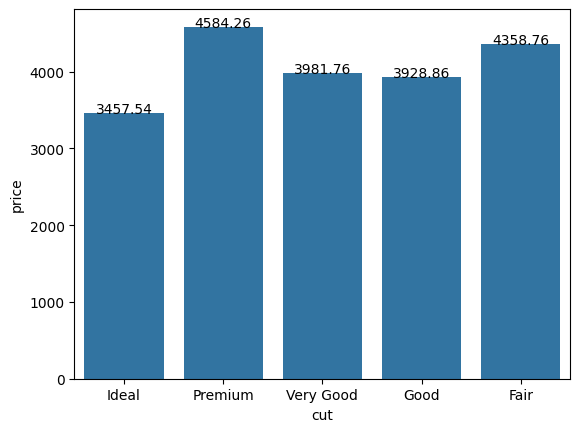

In [18]:
# cut 등급별 평균 price(가격)를 막대그래프로 시각화
g = sns.barplot(x='cut', y='price', data=groupedvalues)

# 막대 위에 가격 값을 표시 (라벨링)
for index, row in groupedvalues.iterrows():
    # row.name → x축 위치, row.price → y축 값
    # round(row.price, 2) → 소수 둘째 자리까지 표시
    g.text(row.name, row.price, round(row.price, 2),
           color='black', ha="center")


<Axes: xlabel='cut', ylabel='price'>

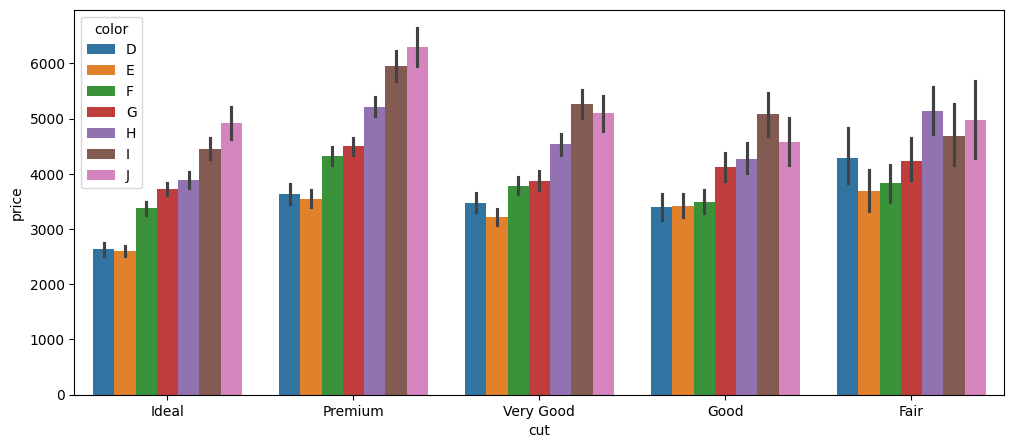

In [20]:
# 그래프 크기 설정 (가로 12, 세로 5)
plt.figure(figsize=(12, 5))

# 다이아몬드 cut 등급별 평균 price를 barplot으로 표현
# hue='color' → 색(color) 등급에 따라 막대를 분리하여 비교 가능
sns.barplot(x='cut', y='price', hue='color', data=df)


<Axes: xlabel='cut', ylabel='price'>

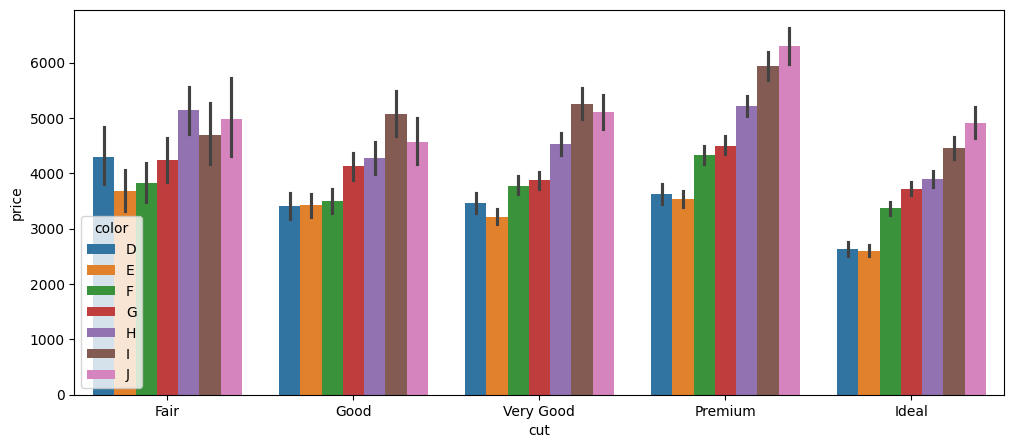

In [ ]:
# 그래프 크기 설정 (가로 12, 세로 5)
plt.figure(figsize=(12, 5))

# cut 등급별 평균 price를 막대그래프로 시각화
# hue='color' → color 등급별로 막대를 구분하여 비교
# order= [...] → cut 등급의 표시 순서를 지정하여 원하는 순서로 정렬
sns.barplot(
    x='cut',
    y='price',
    hue='color',
    order=['Fair', 'Good', 'Very Good', 'Premium', 'Ideal'],
    data=df
)

<Axes: xlabel='cut', ylabel='price'>

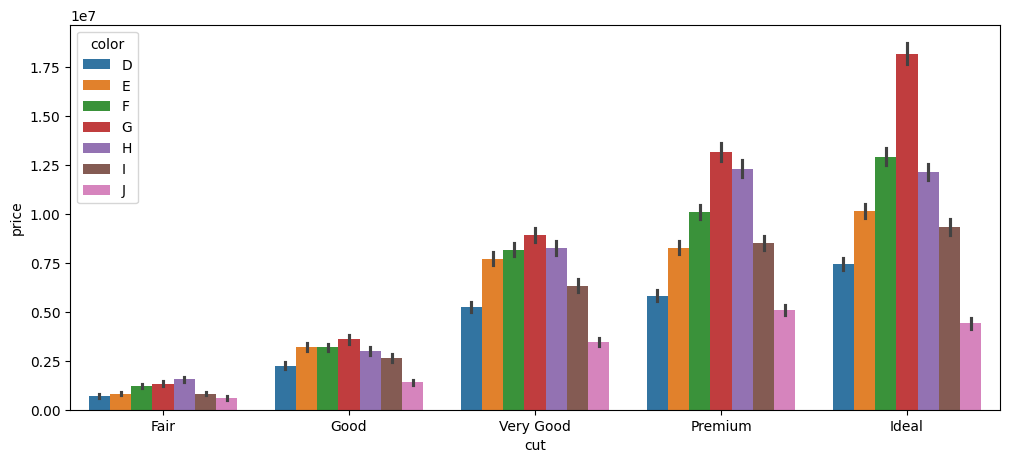

In [ ]:
# 그래프 크기 설정 (가로 12, 세로 5)
plt.figure(figsize=(12, 5))

# cut 등급별 price(가격)의 합계를 barplot으로 시각화
# hue='color' → color 등급별로 구분하여 가격 총합 비교
# order → cut 등급이 출력될 순서를 직접 지정
# estimator=sum → 평균이 아니라 'price 합계'를 계산하여 막대를 그림
sns.barplot(
    x='cut',
    y='price',
    hue='color',
    order=['Fair', 'Good', 'Very Good', 'Premium', 'Ideal'],
    estimator=sum,
    data=df
)

<Axes: xlabel='cut', ylabel='price'>

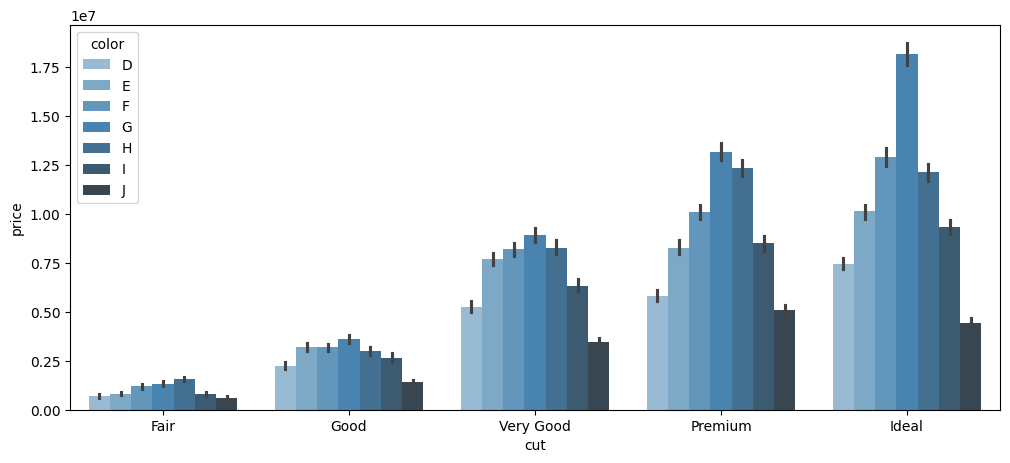

In [24]:
# 그래프 크기 설정 (가로 12, 세로 5)
plt.figure(figsize=(12, 5))

# cut 등급별 price(가격)의 합계를 barplot으로 시각화
# hue='color' → color 등급별로 구분하여 총합 비교
# order → cut 등급 표시 순서를 지정하여 일관된 순서로 출력
# estimator=sum → price 평균이 아니라 '총합' 값을 막대로 표현
# palette="Blues_d" → 파란 계열의 짙은 색조 팔레트 적용
sns.barplot(
    x='cut',
    y='price',
    hue='color',
    order=['Fair', 'Good', 'Very Good', 'Premium', 'Ideal'],
    palette="Blues_d",
    estimator=sum,
    data=df
)

[Text(0.5, 0, 'cut'), Text(0, 0.5, 'price')]

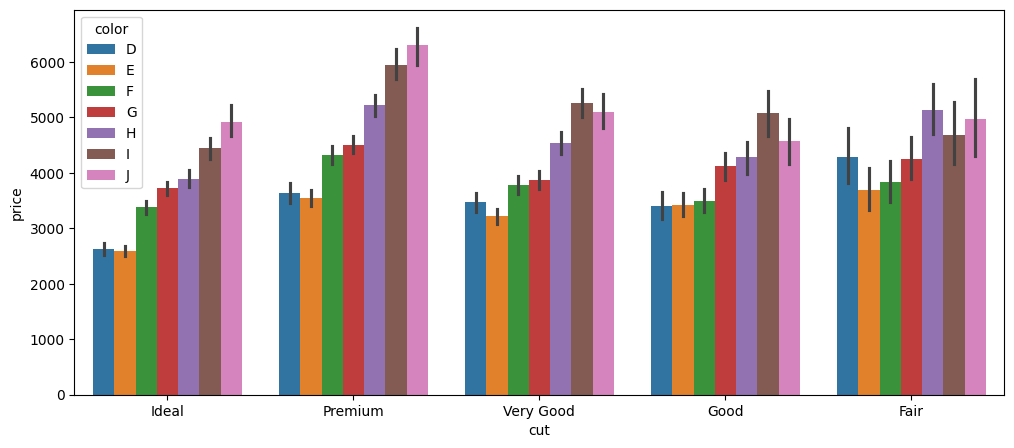

In [25]:
# 그래프 크기 설정 (가로 12, 세로 5)
plt.figure(figsize=(12, 5))

# cut 등급별 평균 price를 barplot으로 시각화
# hue='color' → color 등급을 기준으로 막대를 구분
# set(xlabel, ylabel) → x축과 y축 라벨을 직접 지정
sns.barplot(x='cut', y='price', hue='color', data=df).set(
    xlabel='cut',
    ylabel='price'
)

Text(0.5, 1.0, 'diamonds')

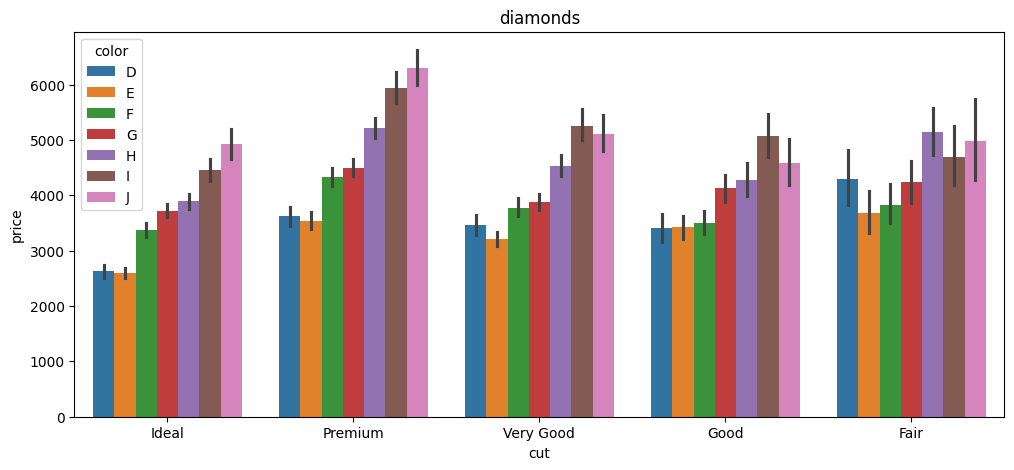

In [26]:
# 그래프 크기 설정 (가로 12, 세로 5)
plt.figure(figsize=(12, 5))

# cut 등급별 평균 price를 barplot으로 시각화
# hue='color' → color 등급에 따라 막대 색을 구분
# set_title('diamonds') → 그래프 제목 설정
sns.barplot(x='cut', y='price', hue='color', data=df).set_title('diamonds')

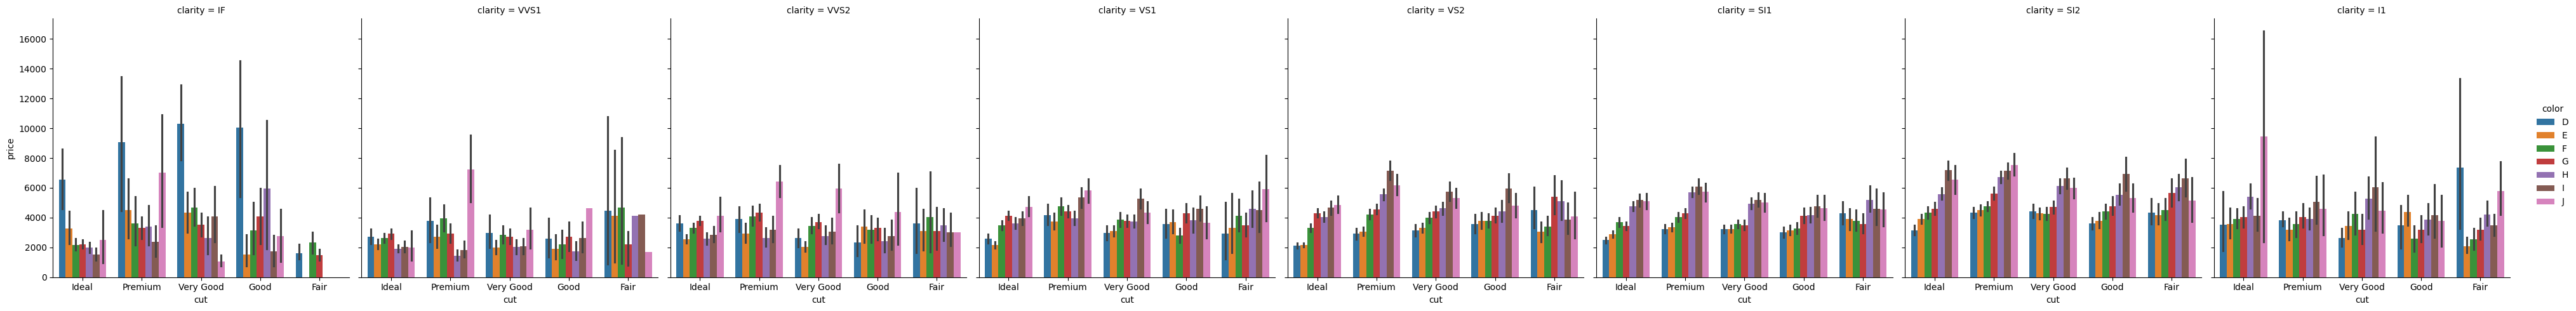

In [28]:
# cut 등급별 price(가격)를 barplot으로 시각화하되,
# hue='color' → color 등급별로 막대를 구분하고
# col='clarity' → clarity 등급별로 그래프를 여러 개의 패널로 나누어 비교
# kind='bar' → 막대그래프 형태 지정
sns.catplot(
    x='cut',
    y='price',
    hue='color',
    col='clarity',
    data=df,
    kind='bar'
)

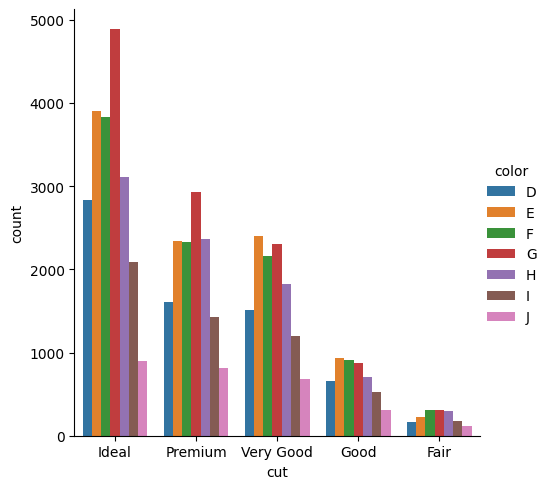

In [29]:
sns.catplot(x ="cut", hue ="color", kind ="count", data = df) 

C:\Users\Shiverlog\AppData\Local\Temp\ipykernel_23648\1138104817.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group = df.groupby(['cut', 'clarity'])


<Axes: xlabel='clarity', ylabel='cut'>

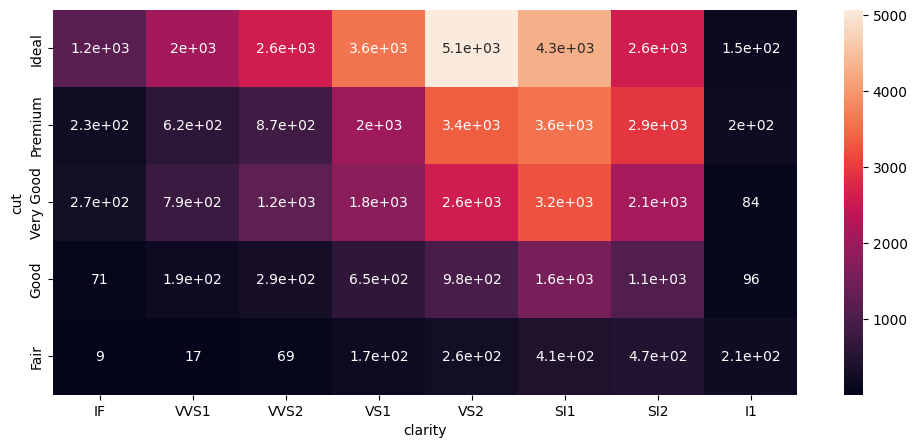

In [32]:
# cut과 clarity 조합별 데이터 개수 계산을 위해 그룹화
group = df.groupby(['cut', 'clarity'])

# 그룹별 개수를 테이블 형태로 변환 (행: cut, 열: clarity)
g = group.size().unstack()

# 그래프 크기 설정 (가로 12, 세로 5)
plt.figure(figsize=(12, 5))

# cut × clarity 조합별 개수를 heatmap으로 시각화
# annot=True → 각 칸에 숫자 표시
sns.heatmap(g, annot=True)

<Axes: xlabel='cut', ylabel='price'>

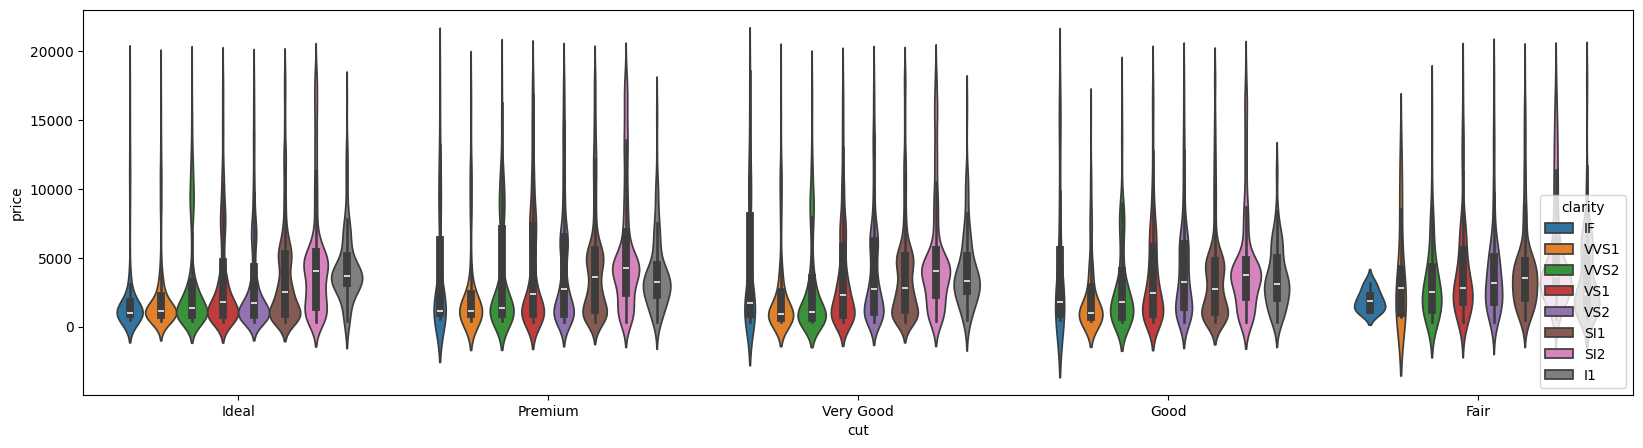

In [33]:
# 그래프 크기 설정 (가로 20, 세로 5)
plt.figure(figsize=(20, 5))

# cut 등급별 price 분포를 바이올린 플롯으로 시각화
# y='price' → 가격 분포를 보여줌
# hue='clarity' → clarity 등급별로 분포를 나누어 비교
# violinplot은 분포의 형태(밀도), 중앙값, 범위 등을 한 번에 확인할 수 있음
sns.violinplot(x="cut", y="price", hue="clarity", data=df)


In [34]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


In [36]:
print(df.cut.unique())
print(df.color.unique())
print(df.clarity.unique())

['Ideal', 'Premium', 'Good', 'Very Good', 'Fair']
Categories (5, object): ['Ideal', 'Premium', 'Very Good', 'Good', 'Fair']
['E', 'I', 'J', 'H', 'F', 'G', 'D']
Categories (7, object): ['D', 'E', 'F', 'G', 'H', 'I', 'J']
['SI2', 'SI1', 'VS1', 'VS2', 'VVS2', 'VVS1', 'I1', 'IF']
Categories (8, object): ['IF', 'VVS1', 'VVS2', 'VS1', 'VS2', 'SI1', 'SI2', 'I1']


In [37]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

# 원본을 보존하기 위해 df를 복사
dfi = df.copy()

# --- cut 컬럼을 숫자로 변환 ---
# LabelEncoder는 문자열 카테고리를 0,1,2,... 형태의 정수로 변환
dfi['cut'] = label_encoder.fit_transform(dfi['cut'])

# 변환된 cut의 클래스 순서 출력 (어떤 문자열이 어떤 숫자로 매핑됐는지 확인)
print(label_encoder.classes_)

# --- color 컬럼 인코딩 ---
dfi['color'] = label_encoder.fit_transform(dfi['color'])
print(label_encoder.classes_)

# --- clarity 컬럼 인코딩 ---
dfi['clarity'] = label_encoder.fit_transform(dfi['clarity'])
print(label_encoder.classes_)


['Fair' 'Good' 'Ideal' 'Premium' 'Very Good']
['D' 'E' 'F' 'G' 'H' 'I' 'J']
['I1' 'IF' 'SI1' 'SI2' 'VS1' 'VS2' 'VVS1' 'VVS2']


In [38]:
dfi.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,2,1,3,61.5,55.0,326,3.95,3.98,2.43
1,0.21,3,1,2,59.8,61.0,326,3.89,3.84,2.31
2,0.23,1,1,4,56.9,65.0,327,4.05,4.07,2.31
3,0.29,3,5,5,62.4,58.0,334,4.20,4.23,2.63
4,0.31,1,6,3,63.3,58.0,335,4.34,4.35,2.75


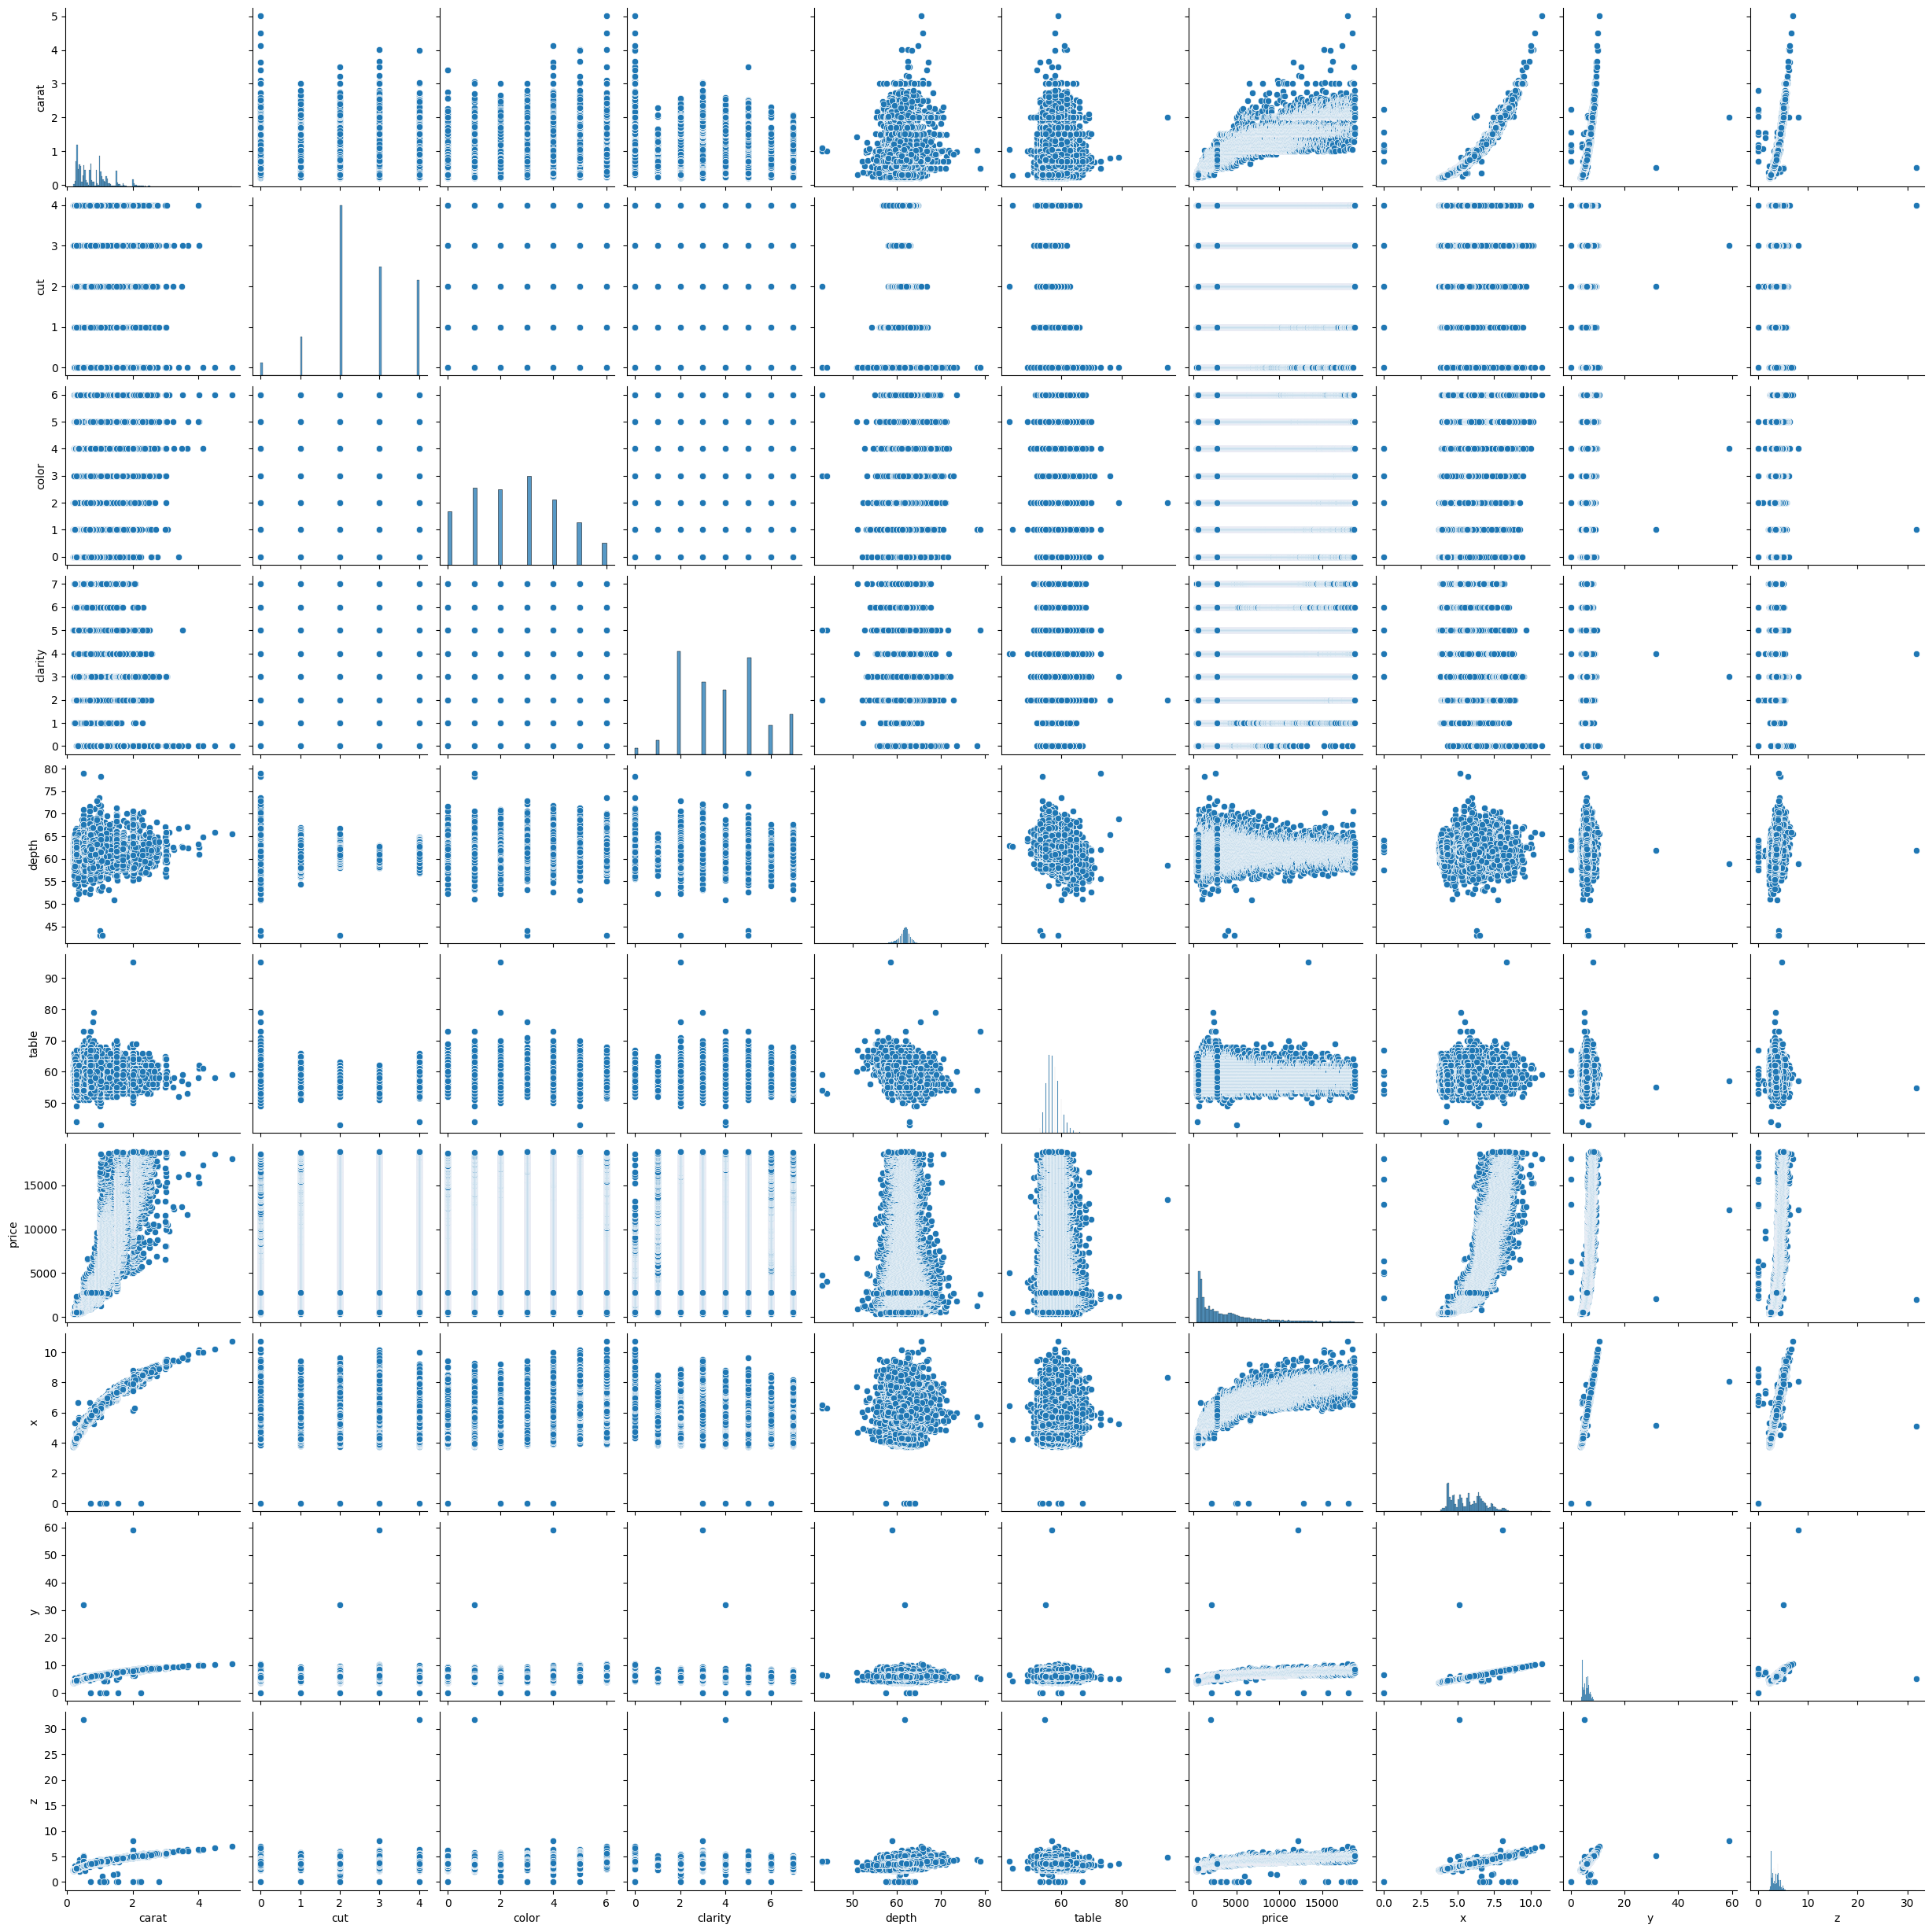

In [39]:
sns.pairplot(dfi)